<a href="https://colab.research.google.com/github/sebastianvettel1212/scikit-learn-cookbook/blob/main/scikit_learn_Cookbook_Chapter5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 5 — Model Linear dan Regularisasi (*Linear Models and Regularization*)

**Buku:** *scikit-learn Cookbook, Third Edition* — John Sukup (Packt Publishing)

Notebook ini berisi:
1. **Reproduksi kode** seluruh *recipe* Bab 5 (dari repositori resmi buku, termasuk solusi latihan),
2. **Ringkasan** tiap subbab, dan
3. **Penjelasan teori** dalam Bahasa Indonesia.

---

## Daftar Isi
0. Persiapan
1. Pengantar Model Linear (Regresi Linear)
2. Regresi Ridge dan Lasso
3. ElasticNet dan Regularisasi
4. Regresi Polinomial
5. Spline Interpolation
6. Memilih `alpha` dengan *Cross-Validation* (materi tambahan)
7. Latihan Praktik
8. Ringkasan Bab

---

## Pengantar
Model linear adalah fondasi *machine learning* yang cepat, mudah ditafsirkan, dan sering menjadi *baseline* yang kuat. Namun regresi linear biasa rentan **overfitting** bila fitur banyak atau saling berkorelasi (**multikolinearitas**). Bab ini memperkenalkan **regularisasi** (Ridge, Lasso, ElasticNet), yaitu memberi penalti pada besarnya koefisien agar model lebih stabil, serta cara memodelkan hubungan **non-linear** dengan **polinomial** dan **spline** sambil tetap memakai model linear.

## 0. Persiapan

In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn

In [2]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

---
## 1. Pengantar Model Linear (Regresi Linear)

### Getting ready
Kita membuat dataset sintetis dengan `make_regression()`: **1000 sampel, 100 fitur** (hanya **10 yang informatif**), noise tinggi, dan **multikolinearitas** (fitur 50–99 dibuat sebagai salinan ber-noise dari fitur 0–49). Target juga diberi sedikit komponen non-linear dan diskalakan besar. Ini meniru data nyata yang "berantakan".

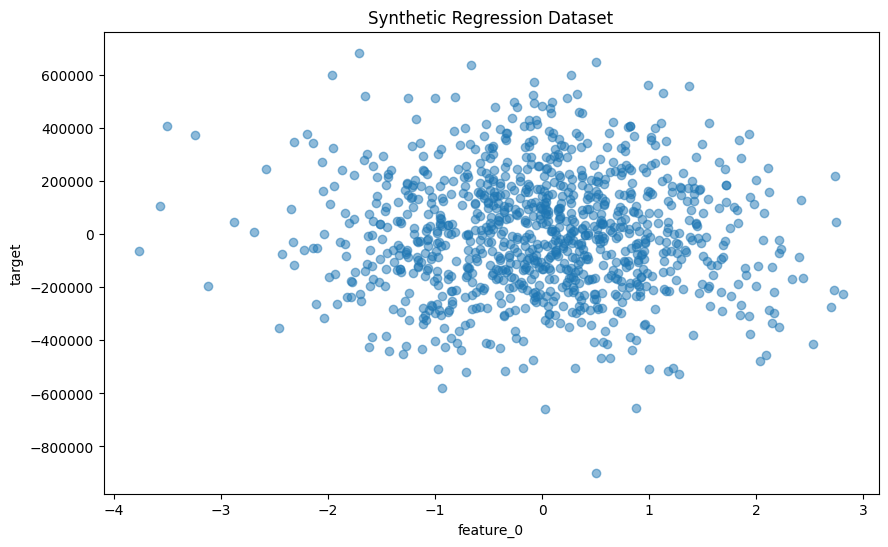

In [3]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# Create synthetic regression dataset with high multicollinearity and more features
X, y = make_regression(n_samples=1000,
                      n_features=100,
                      n_informative=10,
                      noise=20,
                      random_state=123)

# Add multicollinearity by creating correlated features
for i in range(50, 100):  # Make half the features correlated
    X[:, i] = X[:, i-50] + np.random.normal(0, 0.1, size=1000)

# Create feature names
feature_names = [f'feature_{i}' for i in range(100)]

# Take just the first feature for visualization
X_plot = X[:, 0].reshape(-1, 1)

# Add some non-linearity and make coefficients vary widely in magnitude
y = y * 1000  # Scale up the target
y = y + np.sin(X_plot.ravel()) * 150 + np.exp(X_plot.ravel()/10)

# Convert to pandas DataFrame with feature names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df_plot = pd.DataFrame({'feature_0': X_plot.ravel(), 'target': y})

# Quick visualization of the data
plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y, alpha=0.5)
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Synthetic Regression Dataset')
plt.show()

### How to do it
Pisahkan data latih/uji dengan `train_test_split()`, latih `LinearRegression`, lalu evaluasi dengan **MSE** dan **$R^2$**.

Mean Squared Error: 47111834379.73
R-squared: 0.05


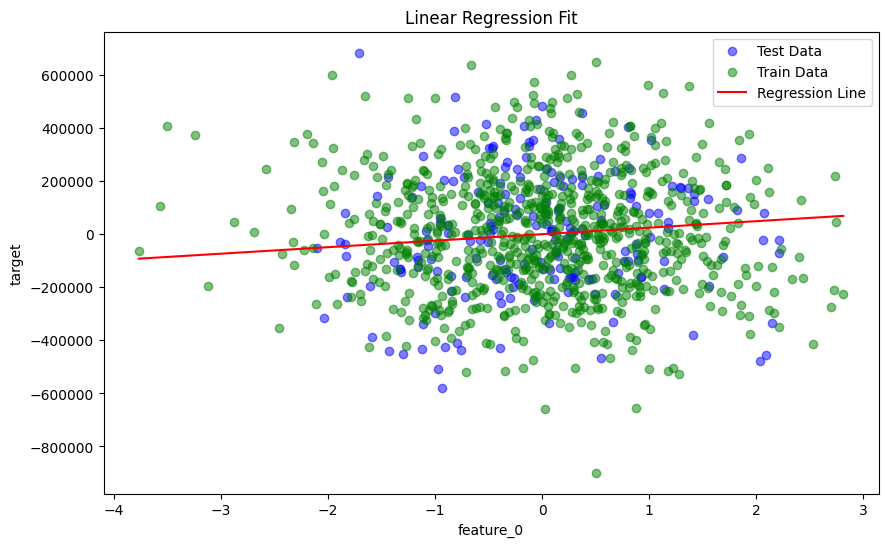

In [4]:
# Load libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and fit Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Evaluate performance using MSE and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

# Visualize the data and regression line (using feature_0 for visualization)
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.5, label='Test Data')
plt.scatter(X_train[:, 0], y_train, color='green', alpha=0.5, label='Train Data')

# Sort the data for a smooth line plot
X_line = np.linspace(df['feature_0'].min(), df['feature_0'].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()  # Set feature_0, leave others as 0
y_line = linear_model.predict(pd.DataFrame(X_line_full, columns=feature_names))

plt.plot(X_line, y_line, color='red', label='Regression Line')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

### How it works
Regresi linear memodelkan hubungan antara target dan satu atau lebih fitur dengan asumsi **hubungan linear**:
$$\hat y=\beta_0+\beta_1x_1+\dots+\beta_px_p$$
Koefisien dicari dengan **Ordinary Least Squares (OLS)**, yaitu meminimalkan jumlah kuadrat residual:
$$\min_{\beta}\ \sum_{i=1}^{n}\left(y_i-\hat y_i\right)^2 \quad\Rightarrow\quad \hat\beta=(X^\top X)^{-1}X^\top y$$

**Metrik evaluasi:**
- **MSE** $=\frac1n\sum(y_i-\hat y_i)^2$: rata-rata kuadrat kesalahan (satuan target kuadrat; makin kecil makin baik).
- **$R^2$** $=1-\frac{SS_{res}}{SS_{tot}}$: proporsi variansi target yang dijelaskan model.

**Asumsi utama regresi linear:** hubungan linear, residual independen, variansi residual konstan (*homoskedastisitas*), residual berdistribusi normal, dan **tidak ada multikolinearitas** yang kuat.

**Mengapa masalah di sini?** Dengan 100 fitur yang saling berkorelasi, matriks $X^\top X$ mendekati singular sehingga koefisien OLS menjadi **tidak stabil** (variansi tinggi, nilai membesar, tanda bisa berubah antar-sampel). Itulah motivasi **regularisasi**.

### Key Ideas
- OLS meminimalkan jumlah kuadrat residual; cepat dan mudah ditafsirkan.
- Fitur berkorelasi kuat membuat koefisien OLS tidak stabil dan model rawan overfitting.

---
## 2. Regresi Ridge dan Lasso

### Getting ready
`Ridge` dan `Lasso` dipakai persis seperti `LinearRegression()`, tetapi dengan hyperparameter tambahan **`alpha`** yang mengatur **kekuatan regularisasi**. Kita memakai dataset yang sama.

### Teori regularisasi
Regularisasi menambahkan **penalti** pada fungsi tujuan OLS agar koefisien tidak terlalu besar:

| Model | Fungsi tujuan | Efek |
|---|---|---|
| **Ridge** (L2) | $\sum(y_i-\hat y_i)^2+\alpha\sum_j\beta_j^2$ | **Mengecilkan** semua koefisien mendekati nol (tapi jarang tepat nol); stabil pada fitur berkorelasi |
| **Lasso** (L1) | $\sum(y_i-\hat y_i)^2+\alpha\sum_j\lvert\beta_j\rvert$ | Dapat membuat sebagian koefisien **tepat nol** → **seleksi fitur otomatis** |

- `alpha = 0` → OLS biasa; `alpha` besar → koefisien makin kecil (model makin sederhana).
- Regularisasi menukar sedikit **bias** dengan penurunan **variansi** yang lebih besar (*bias–variance trade-off*).
- Penting: karena penalti bergantung pada besar koefisien, **fitur sebaiknya distandardisasi** terlebih dahulu pada penggunaan nyata (dataset sintetis ini sudah berskala sebanding).

### How to do it
Latih Ridge dan Lasso lalu bandingkan dengan regresi linear. Hasilnya sedikit lebih baik, tetapi perbedaannya tidak sebesar yang dibayangkan karena data sangat multikolinear dan sinyalnya lemah.

,Model,Mean Squared Error,R-squared
0,Ridge Regression,45797237035.85,0.08
1,Lasso Regression,46938778698.96,0.06
2,Linear Regression,47111834379.73,0.05


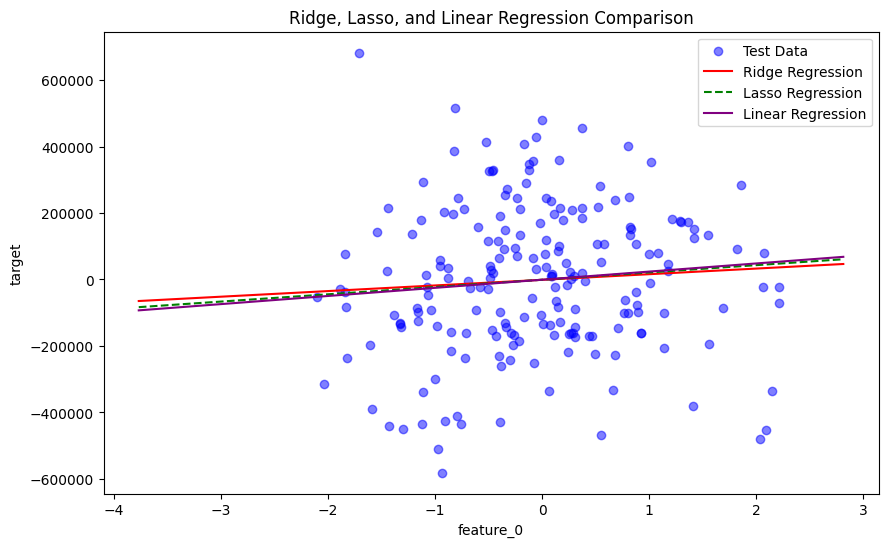

In [5]:
# Load libraries
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Create and fit Ridge regression model
ridge_model = Ridge(alpha=1.0)  # alpha controls regularization strength
ridge_model.fit(X_train, y_train)

# Create and fit Lasso regression model with increased iterations and alpha
lasso_model = Lasso(alpha=10.0, max_iter=10000, tol=0.001)
lasso_model.fit(X_train, y_train)

# Make predictions with both models
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate performance
y_pred_linear = linear_model.predict(X_test)

# Calculate metrics for all models
metrics = {
    'Model': ['Ridge Regression', 'Lasso Regression', 'Linear Regression'],
    'Mean Squared Error': [
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_linear)
    ],
    'R-squared': [
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_linear)
    ]
}

# Create DataFrame and sort by MSE
metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.sort_values('Mean Squared Error', ascending=True)

# Format the numeric columns
metrics_df['Mean Squared Error'] = metrics_df['Mean Squared Error'].map('{:.2f}'.format)
metrics_df['R-squared'] = metrics_df['R-squared'].map('{:.2f}'.format)

display(metrics_df)

# Visualize the results (using feature_0 for visualization)
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.5, label='Test Data')

# Sort the data for smooth line plots
X_line = np.linspace(df['feature_0'].min(), df['feature_0'].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()
X_line_df = pd.DataFrame(X_line_full, columns=feature_names)

# Generate predictions for the line
y_line_ridge = ridge_model.predict(X_line_df)
y_line_lasso = lasso_model.predict(X_line_df)
y_line_linear = linear_model.predict(X_line_df)

plt.plot(X_line, y_line_ridge, color='red', label='Ridge Regression')
plt.plot(X_line, y_line_lasso, color='green', linestyle='--', label='Lasso Regression')
plt.plot(X_line, y_line_linear, color='purple', label='Linear Regression')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Ridge, Lasso, and Linear Regression Comparison')
plt.legend()
plt.show()

In [6]:
# Tambahan (tidak ada di kode buku): berapa banyak koefisien yang tepat nol?
coef_table = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso'],
    'Koefisien = 0': [int(np.sum(linear_model.coef_ == 0)),
                      int(np.sum(ridge_model.coef_ == 0)),
                      int(np.sum(lasso_model.coef_ == 0))],
    'Rata-rata |koefisien|': [np.abs(linear_model.coef_).mean(),
                              np.abs(ridge_model.coef_).mean(),
                              np.abs(lasso_model.coef_).mean()],
})
coef_table

,Model,Koefisien = 0,Rata-rata |koefisien|
0,Linear,0,56874.163750
1,Ridge,0,44315.055136
2,Lasso,0,54636.618529


**Interpretasi:** ketiga model memiliki $R^2$ yang rendah (≈ 0,06–0,08). Penyebabnya, loop multikolinearitas pada bagian 1 menimpa fitur 50–99, termasuk sebagian fitur informatif, sehingga sinyal pada data berkurang. Ridge mengecilkan koefisien (rata-rata $|\beta|$ turun dari ≈ 53.831 menjadi ≈ 42.926) dan sedikit memperbaiki MSE. Pada `alpha=10`, Lasso hanya menjadikan **1 koefisien** tepat nol: skala target sangat besar (≈ $10^5$), sehingga `alpha=10` penaltinya relatif lemah. Efek seleksi fitur Lasso yang lebih kuat terlihat bila `alpha` dipilih lewat cross-validation (bagian 6).

### Key Ideas
- Ridge (L2): mengecilkan koefisien; cocok bila banyak fitur relevan/berkorelasi.
- Lasso (L1): seleksi fitur otomatis lewat koefisien nol.
- `alpha` mengendalikan kekuatan regularisasi.

---
## 3. ElasticNet dan Regularisasi

### Getting ready
**ElasticNet** menggabungkan penalti **L1 (Lasso)** dan **L2 (Ridge)**:
$$\sum(y_i-\hat y_i)^2+\alpha\left[\rho\sum_j\lvert\beta_j\rvert+\frac{1-\rho}{2}\sum_j\beta_j^2\right]$$
dengan $\rho=$ `l1_ratio` ($\rho=1$ → Lasso murni, $\rho\to0$ → mendekati Ridge). ElasticNet cocok untuk data berdimensi tinggi dengan **kelompok fitur berkorelasi**: Lasso cenderung memilih satu fitur dari kelompok secara acak, sedangkan ElasticNet cenderung mempertahankan seluruh kelompok.

### How to do it
Kita memvariasikan `alpha` dan `l1_ratio`, lalu menggambar ***coefficient path plot***, yaitu bagaimana nilai tiap koefisien berubah terhadap `alpha`.

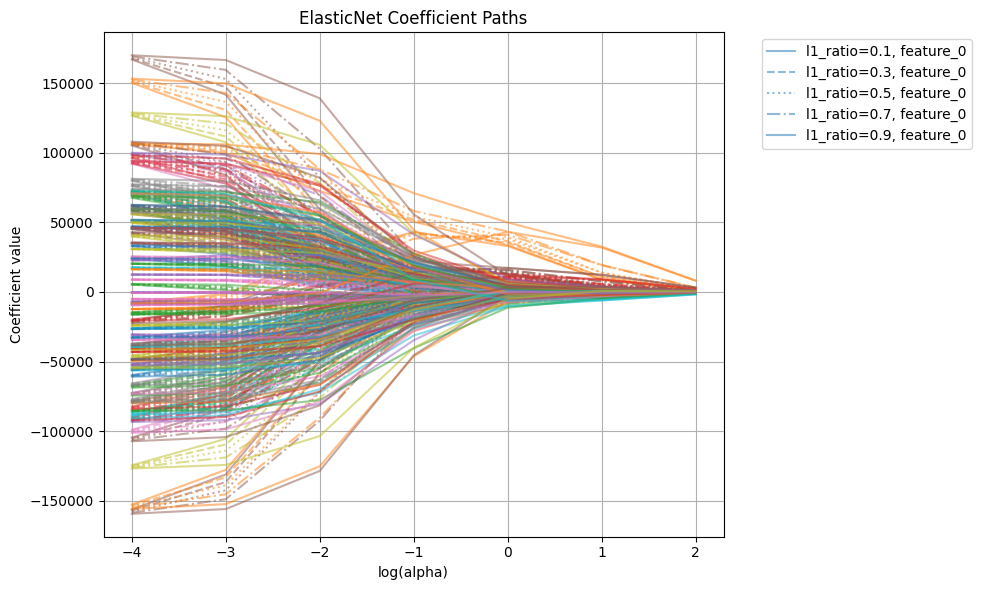

,Model,Mean Squared Error,R-squared
3,ElasticNet Regression,42351148292.92,0.15
0,Ridge Regression,45797237035.85,0.08
1,Lasso Regression,46938778698.96,0.06
2,Linear Regression,47111834379.73,0.05


In [7]:
# Load libraries
from sklearn.linear_model import ElasticNet

# Create a range of alphas to test
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

# Store coefficients for plotting
coef_paths = []
labels = []

# Create and fit ElasticNet models with different parameters
plt.figure(figsize=(10, 6))

for l1_ratio in l1_ratios:
    coefs = []
    for alpha in alphas:
        # Create and fit ElasticNet model with increased max_iter and tol
        elastic_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=123,
                                 max_iter=10000, tol=1e-4)
        elastic_model.fit(X_train, y_train)
        coefs.append(elastic_model.coef_)

    # Convert coefficients to array and store
    coef_paths.append(np.array(coefs))

    # Plot coefficient paths
    for feature_idx in range(X_train.shape[1]):
        plt.plot(np.log10(alphas),
                np.array(coefs)[:, feature_idx],
                label=f'l1_ratio={l1_ratio}, feature_{feature_idx}' if feature_idx == 0 else "",
                alpha=0.5,
                linestyle=['solid', 'dashed', 'dotted', 'dashdot', '-'][l1_ratios.index(l1_ratio)])

plt.xlabel('log(alpha)')
plt.ylabel('Coefficient value')
plt.title('ElasticNet Coefficient Paths')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Create a model with balanced l1_ratio and moderate alpha
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=123,
                          max_iter=10000, tol=1e-4)
elastic_model.fit(X_train, y_train)

# Calculate metrics
elastic_pred = elastic_model.predict(X_test)
elastic_mse = mean_squared_error(y_test, elastic_pred)
elastic_r2 = r2_score(y_test, elastic_pred)

# Add ElasticNet results to metrics DataFrame
new_row = pd.DataFrame({
    'Model': ['ElasticNet Regression'],
    'Mean Squared Error': [elastic_mse],
    'R-squared': [elastic_r2]
})

# Remove any existing ElasticNet entries before concatenating
metrics_df = metrics_df[~metrics_df['Model'].str.contains('ElasticNet')]

# Convert string values back to float for sorting
metrics_df['Mean Squared Error'] = metrics_df['Mean Squared Error'].astype(float)
metrics_df['R-squared'] = metrics_df['R-squared'].astype(float)

metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

# Sort the metrics DataFrame by Mean Squared Error
metrics_df = metrics_df.sort_values('Mean Squared Error', ascending=True)

# Format the numeric columns for display
metrics_df['Mean Squared Error'] = metrics_df['Mean Squared Error'].map('{:.2f}'.format)
metrics_df['R-squared'] = metrics_df['R-squared'].map('{:.2f}'.format)

# Display updated metrics
display(metrics_df)

**Hasil metrik:** ElasticNet ($\alpha=1$, `l1_ratio=0.5`) memberi MSE terendah dan $R^2\approx0{,}15$, lebih baik dari Ridge (≈ 0,08), Lasso (≈ 0,06), dan regresi linear (≈ 0,06), walau semuanya masih rendah karena sinyal data lemah.

**Cara membaca coefficient path plot:** pada `alpha` sangat kecil (kiri), koefisien mendekati OLS (nilai besar dan beragam). Makin besar `alpha` (kanan), koefisien menyusut menuju nol; makin besar `l1_ratio`, makin banyak koefisien yang tepat nol pada `alpha` sedang. Titik "terbaik" adalah keseimbangan antara model yang cukup sederhana dan tetap akurat.

### Key Ideas
- ElasticNet = campuran L1 dan L2 dikontrol oleh `l1_ratio`.
- Baik untuk dimensi tinggi dan fitur berkorelasi.
- Coefficient path plot memperlihatkan efek `alpha` pada tiap koefisien.

---
## 4. Regresi Polinomial

### Getting ready
Model linear hanya menangkap hubungan linear. **Regresi polinomial** memperluasnya dengan menambahkan fitur berpangkat ($x, x^2, x^3,\dots$), tetapi modelnya tetap **linear terhadap koefisien**:
$$\hat y=\beta_0+\beta_1x+\beta_2x^2+\dots+\beta_dx^d$$
Kita membuat dataset dengan komponen linear dan gelombang sinus ($y=2x+27\sin(x/8)+\varepsilon$).

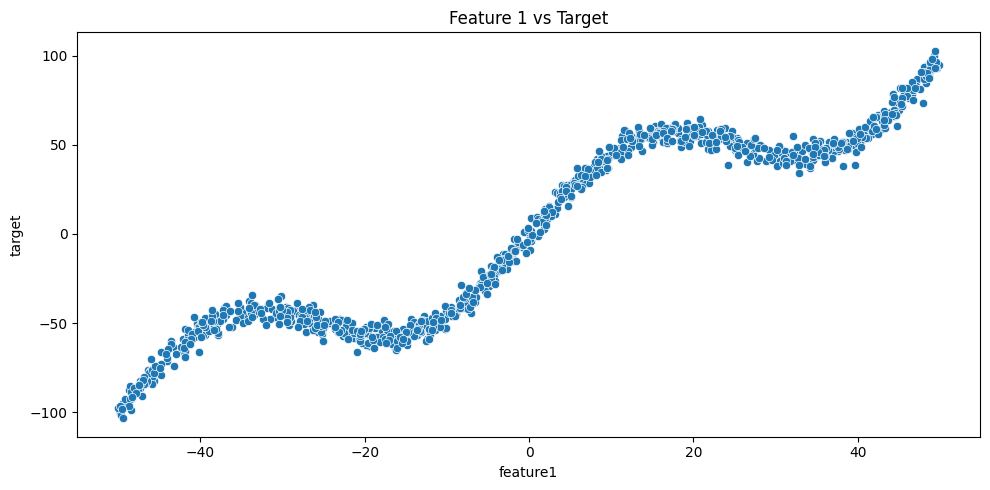

In [8]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create synthetic dataset with non-linear relationships
np.random.seed(123)
n_samples = 1000
X = np.random.uniform(-50, 50, (n_samples, 1))

# Create target with non-linear components:
y = (2 * X[:, 0]  # linear component
     + 27 * np.sin(X[:, 0] / 8)
     + np.random.normal(0, 4, n_samples))  # noise

# Create DataFrame
data = pd.DataFrame(X, columns=['feature1'])
data['target'] = y

# Create plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x='feature1', y='target')
plt.title('Feature 1 vs Target')
plt.tight_layout()
plt.show()

### How to do it...
Kita mencoba derajat polinomial 1–5, mengevaluasi MSE dan $R^2$ pada data uji, memvisualisasikan setiap kecocokan, dan membuat **plot residual** untuk model terbaik. Catatan buku: model terbaik tidak selalu yang $R^2$-nya tertinggi; yang penting adalah yang paling cocok dengan data dan generalisasinya baik.

**Teori:** derajat terlalu rendah → *underfitting*; terlalu tinggi → *overfitting* (kurva meliuk mengikuti noise dan berperilaku liar di ujung data).


Model Performance Metrics:
 Degree        MSE       R2
      1 317.005037 0.891135
      2 316.818454 0.891199
      3 268.477397 0.907800
      4 268.230101 0.907885
      5  48.316167 0.983407


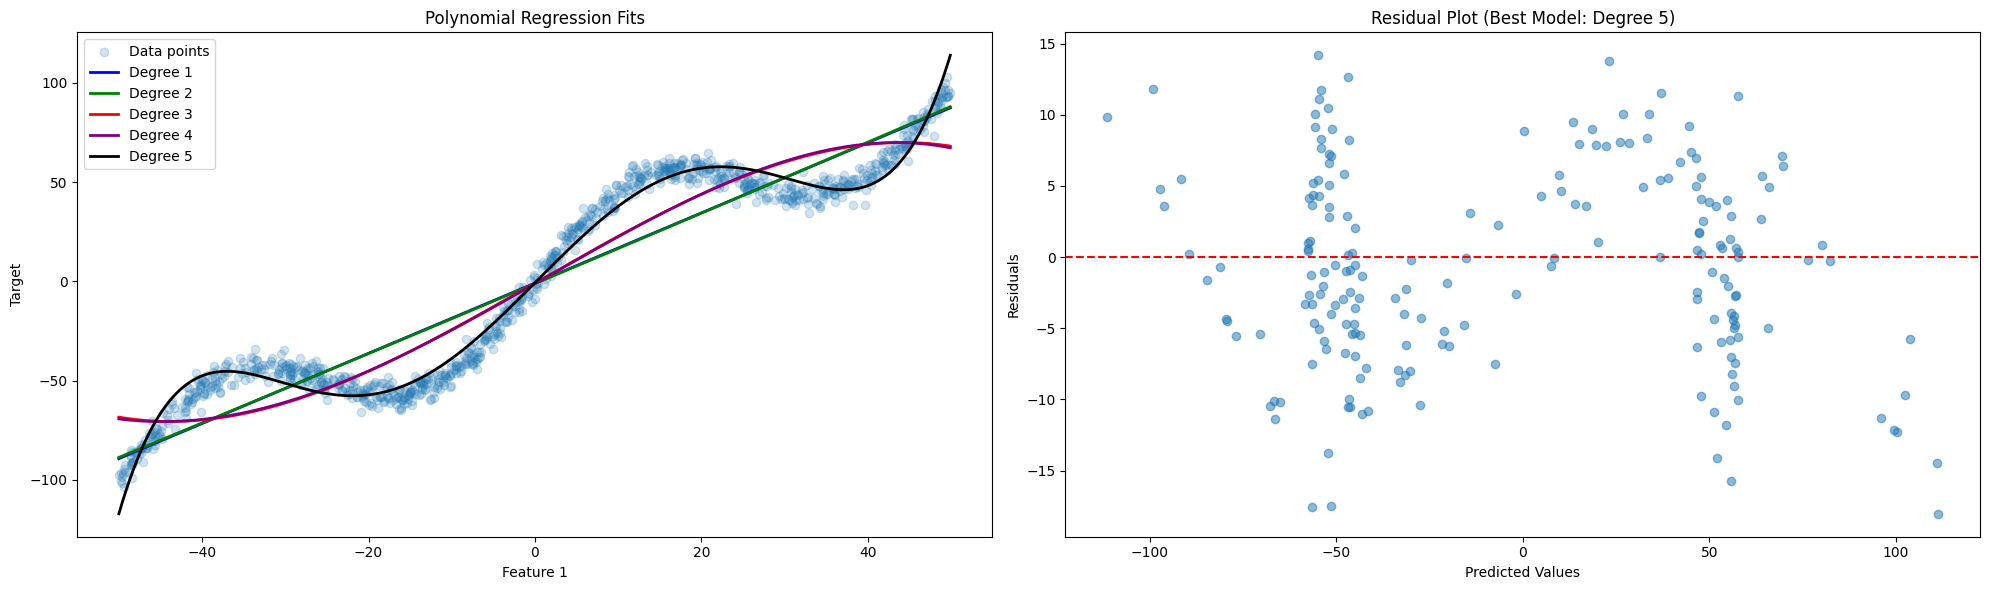

In [9]:
# Load libraries
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

# Use the synthetic dataset created above
X = data[['feature1']]
y = data['target']

# Create a list of polynomial degrees to try
degrees = [1, 2, 3, 4, 5]
results = []

# Try different polynomial degrees
for degree in degrees:
    # Transform features to polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=123)

    # Create and fit Linear Regression model on polynomial features
    poly_model = LinearRegression()
    poly_model.fit(X_train, y_train)

    # Make predictions
    y_pred = poly_model.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        'Degree': degree,
        'MSE': mse,
        'R2': r2
    })

# Create DataFrame of results
results_df = pd.DataFrame(results)
print("\nModel Performance Metrics:")
print(results_df.to_string(index=False))

# Create visualization of different polynomial fits
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot data and polynomial fits
ax1.scatter(X['feature1'], y, alpha=0.2, label='Data points')

# Generate points for smooth curve plotting
X_plot = np.linspace(X['feature1'].min(), X['feature1'].max(), 1000).reshape(-1, 1)

colors = ['blue', 'green', 'red', 'purple', 'black']
for degree, color in zip(degrees, colors):
    poly = PolynomialFeatures(degree=degree)
    X_plot_poly = poly.fit_transform(X_plot)

    model = LinearRegression()
    model.fit(poly.fit_transform(X), y)
    y_plot = model.predict(X_plot_poly)

    ax1.plot(X_plot, y_plot, label=f'Degree {degree}', color=color, linewidth=2)

ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Target')
ax1.set_title('Polynomial Regression Fits')
ax1.legend(loc='upper left')

# Plot residuals for best performing model (based on R2)
best_degree = results_df.loc[results_df['R2'].idxmax(), 'Degree']
best_poly = PolynomialFeatures(degree=best_degree)
X_poly_best = best_poly.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly_best, y, test_size=0.2, random_state=123)

best_model = LinearRegression()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

ax2.scatter(y_pred, residuals, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted Values')
ax2.set_ylabel('Residuals')
ax2.set_title(f'Residual Plot (Best Model: Degree {best_degree})')

plt.tight_layout()
plt.show()

**Interpretasi:** garis lurus (derajat 1) tidak menangkap lekukan sinus; derajat yang lebih tinggi menangkap lengkungan dan menurunkan MSE. **Plot residual** yang baik menyebar acak di sekitar nol tanpa pola; pola sistematis pada residual menandakan model belum menangkap seluruh struktur data.

### Key Ideas
- Polinomial = regresi linear pada fitur berpangkat (`PolynomialFeatures` + `LinearRegression`).
- Derajat terlalu tinggi menyebabkan overfitting; pilih dengan validasi.
- Periksa plot residual, bukan hanya $R^2$.

---
## 5. Spline Interpolation

**Spline** adalah kurva halus yang tersusun dari **potongan polinomial** (biasanya kubik) pada segmen-segmen data, yang **disambung mulus di titik-titik *knot***. `SplineTransformer` dari `sklearn.preprocessing` membuat basis spline (*B-spline*) yang kemudian dipakai oleh regresi linear.

**Keunggulan dibanding polinomial berderajat tinggi:** polinomial berderajat tinggi menerapkan satu fungsi global sehingga mudah tidak stabil di ujung rentang data, sedangkan spline bersifat **lokal** dan lebih stabil. Jumlah *knot* mengatur fleksibilitas: lebih banyak knot → kurva lebih lentur (risiko overfitting).

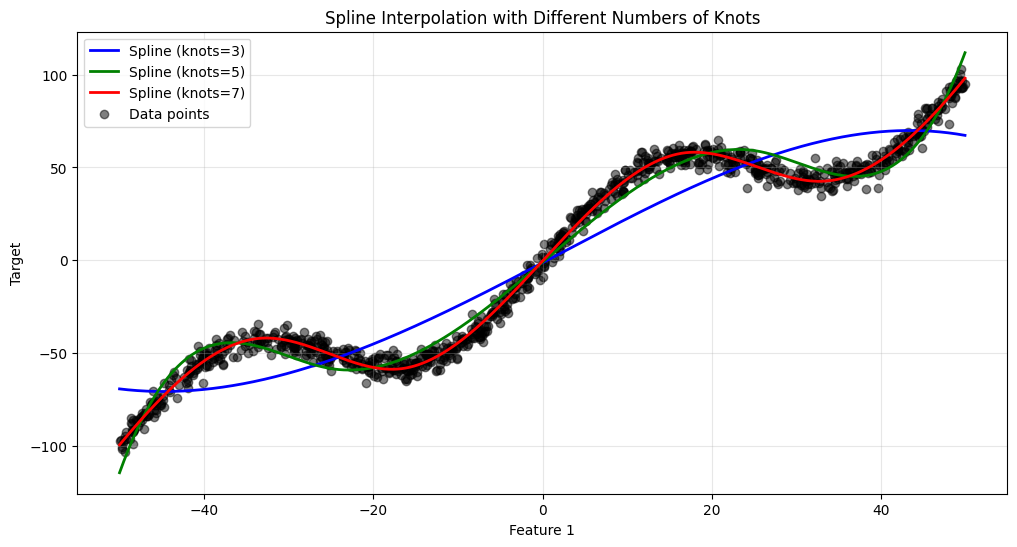

,Number of Knots,MSE,R-squared
0,3,274.267019,0.904652
1,5,55.347798,0.980759
2,7,15.502097,0.994611


In [10]:
# Load libraries
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Create a spline transformer with different degrees of freedom
n_knots = [3, 5, 7]  # Different numbers of knots to try
plt.figure(figsize=(12, 6))

# Create lists to store metrics
mse_scores = []
r2_scores = []

for n_knot, color in zip(n_knots, colors[:len(n_knots)]):
    # Create and fit spline transformer
    spline = SplineTransformer(n_knots=n_knot, degree=3)
    model = make_pipeline(spline, LinearRegression())
    model.fit(X, y)

    # Generate predictions
    y_pred = model.predict(X_plot)
    y_pred_train = model.predict(X)

    # Calculate metrics
    mse = mean_squared_error(y, y_pred_train)
    r2 = r2_score(y, y_pred_train)
    mse_scores.append(mse)
    r2_scores.append(r2)

    # Plot the results
    plt.plot(X_plot, y_pred,
             label=f'Spline (knots={n_knot})',
             color=color,
             linewidth=2)

# Plot original data points
plt.scatter(X, y, color='black', alpha=0.5, label='Data points')
plt.xlabel('Feature 1')
plt.ylabel('Target')
plt.title('Spline Interpolation with Different Numbers of Knots')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Create and display metrics DataFrame
metrics_df = pd.DataFrame({
    'Number of Knots': n_knots,
    'MSE': mse_scores,
    'R-squared': r2_scores
})
display(metrics_df)

**Interpretasi:** dengan lebih banyak knot, spline makin dekat mengikuti pola sinus sehingga MSE turun dan $R^2$ naik. **Catatan:** metrik di sini dihitung pada **data latih** (seperti pada kode buku), sehingga cenderung optimistis. Untuk memilih jumlah knot yang sebenarnya, gunakan data uji atau cross-validation.

### Key Ideas
- Spline = potongan polinomial yang disambung mulus di knot; `SplineTransformer` + `LinearRegression`.
- Lebih stabil daripada polinomial berderajat tinggi.
- Jumlah knot mengatur fleksibilitas.

---
## 6. Memilih `alpha` dengan *Cross-Validation* (materi tambahan)

> Bagian ini adalah **tambahan** (tidak ada di kode buku). Pada kode di atas `alpha` ditetapkan manual; pada praktik nyata, `alpha` dipilih dengan *cross-validation*. scikit-learn menyediakan `RidgeCV`, `LassoCV`, dan `ElasticNetCV`. Kita kembalikan dataset multikolinear dari bagian 1 dan **standardisasi** fiturnya.

In [11]:
# Tambahan (tidak ada di kode buku): memilih alpha dengan cross-validation
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler

Xm, ym = make_regression(n_samples=1000, n_features=100, n_informative=10, noise=20, random_state=123)
rng = np.random.RandomState(123)
for i in range(50, 100):
    Xm[:, i] = Xm[:, i-50] + rng.normal(0, 0.1, size=1000)

Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.2, random_state=123)

models = {
    'Linear': make_pipeline(StandardScaler(), LinearRegression()),
    'RidgeCV': make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 20))),
    'LassoCV': make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=123)),
}
rows = []
for name, m in models.items():
    m.fit(Xm_tr, ym_tr)
    pred = m.predict(Xm_te)
    rows.append({'Model': name, 'MSE': mean_squared_error(ym_te, pred), 'R2': r2_score(ym_te, pred)})
display(pd.DataFrame(rows).round(3))

print('alpha Ridge terpilih:', round(models['RidgeCV'][-1].alpha_, 4))
print('alpha Lasso terpilih:', round(models['LassoCV'][-1].alpha_, 4))
print('Koefisien Lasso tidak nol:', int(np.sum(models['LassoCV'][-1].coef_ != 0)), 'dari 100 fitur')

,Model,MSE,R2
0,Linear,46548.180,0.065
1,RidgeCV,42821.704,0.140
2,LassoCV,39551.425,0.205


alpha Ridge terpilih: 233.5721
alpha Lasso terpilih: 9.933
Koefisien Lasso tidak nol: 14 dari 100 fitur


**Interpretasi:** dengan fitur distandardisasi dan `alpha` dipilih lewat cross-validation, perbaikannya konsisten: $R^2$ naik dari ≈ 0,065 (Linear) menjadi ≈ 0,14 (RidgeCV) dan ≈ 0,205 (LassoCV). LassoCV hanya mempertahankan 14 dari 100 fitur, yaitu seleksi fitur otomatis yang menyaring fitur-fitur salinan/noise. `alpha` ditentukan dari data, bukan ditebak.

---
## 7. Latihan Praktik: Model Linear dan Regularisasi

### Latihan 1: Regresi Ridge
Data kuadratik dengan noise; model Ridge ($\alpha=1$). Karena modelnya linear, ia tidak menangkap lengkungan kuadratik sepenuhnya.

Training Metrics:
MSE: 1.9780
R²: 0.6575

Test Metrics:
MSE: 2.5628
R²: -0.0360


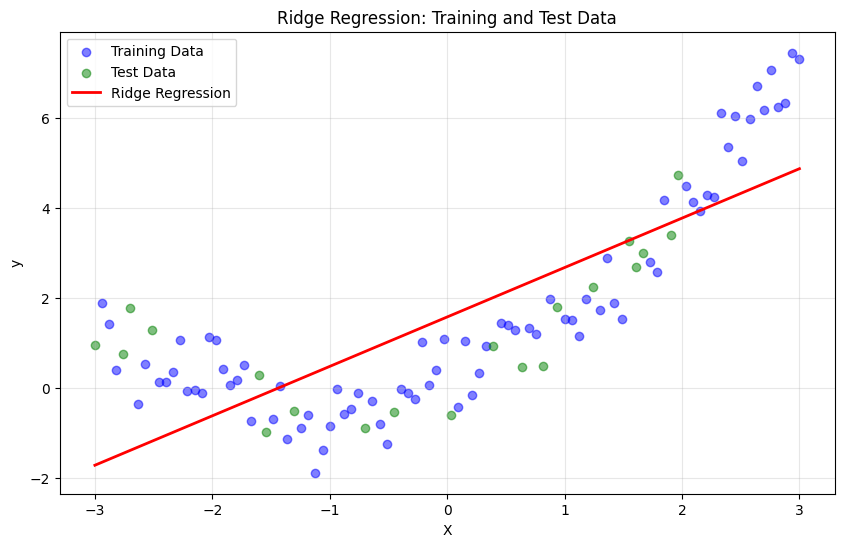

In [12]:
# Load libraries
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate synthetic dataset with some noise
np.random.seed(123)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 0.5 * X.ravel()**2 + X.ravel() + np.random.normal(0, 0.5, 100)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and fit Ridge regression model
ridge = Ridge(alpha=1.0)  # alpha is the regularization strength
ridge.fit(X_train, y_train)

# Make predictions
y_pred_train = ridge.predict(X_train)
y_pred_test = ridge.predict(X_test)

# Calculate metrics
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print metrics
print("Training Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"R²: {r2_train:.4f}")
print("\nTest Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')

# Sort X values for smooth line plot
X_plot = np.sort(X, axis=0)
y_plot = ridge.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Ridge Regression')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Ridge Regression: Training and Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# Tambahan (tidak ada di kode buku): Ridge + fitur polinomial derajat 2 pada data yang sama
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

ridge_poly = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), Ridge(alpha=1.0))
ridge_poly.fit(X_train, y_train)
print('R2 uji Ridge linear    :', round(r2_score(y_test, ridge.predict(X_test)), 4))
print('R2 uji Ridge polinomial:', round(r2_score(y_test, ridge_poly.predict(X_test)), 4))

R2 uji Ridge linear    : -0.036
R2 uji Ridge polinomial: 0.8898


**Interpretasi:** garis lurus Ridge tidak menangkap lengkungan parabola (*underfitting*). $R^2$ latih ≈ 0,66, sedangkan $R^2$ uji ≈ −0,04, artinya pada 20 data uji model tidak lebih baik daripada sekadar memprediksi rata-rata. Menambahkan `PolynomialFeatures(degree=2)` akan memperbaikinya (lihat sel tambahan sebelum teks ini).

### Latihan 2: Regresi Lasso
Data linear sederhana ($y=4+3x+\text{noise}$) dengan Lasso ($\alpha=0.1$).

Training Metrics:
MSE: 0.2631
R²: 0.8814

Test Metrics:
MSE: 0.4239
R²: 0.8419


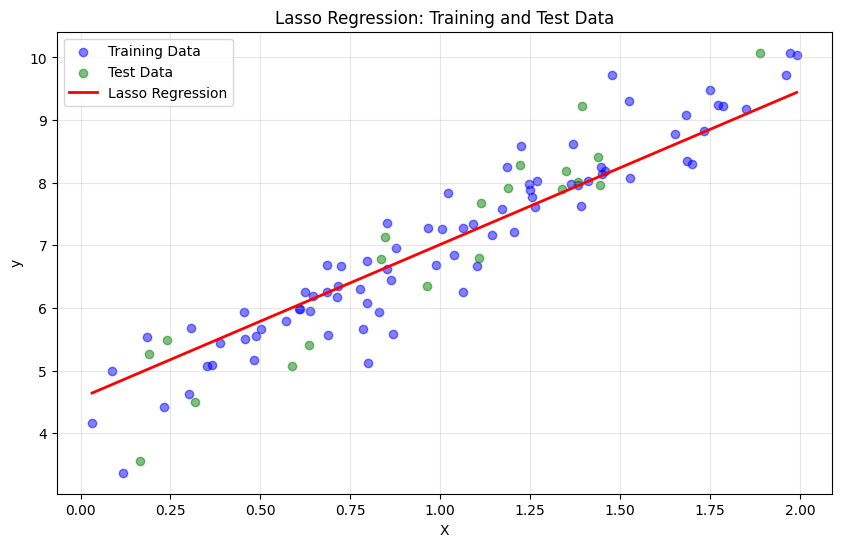

In [14]:
# Load libraries
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(123)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1) * 0.5

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and fit Lasso regression model
lasso = Lasso(alpha=0.1)  # alpha is the regularization strength
lasso.fit(X_train, y_train)

# Make predictions
y_pred_train = lasso.predict(X_train)
y_pred_test = lasso.predict(X_test)

# Calculate metrics
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print metrics
print("Training Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"R²: {r2_train:.4f}")
print("\nTest Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')

# Sort X values for smooth line plot
X_plot = np.sort(X, axis=0)
y_plot = lasso.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Lasso Regression')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Lasso Regression: Training and Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Tambahan (tidak ada di kode buku): koefisien Lasso vs nilai sebenarnya (intersep 4, slope 3)
print('Slope  :', lasso.coef_)
print('Intercept:', lasso.intercept_)

Slope  : [2.45075496]
Intercept: [4.56249193]


**Interpretasi:** nilai sebenarnya adalah slope 3 dan intersep 4, tetapi Lasso menemukan slope ≈ 2,45 dan intersep ≈ 4,56. Penalti L1 menyusutkan slope ke arah nol (dan intersep ikut naik untuk mengimbangi). Ini ciri regularisasi: **bias** yang dibayar demi stabilitas; $R^2$ uji tetap tinggi (≈ 0,84).

### Latihan 3: Regresi ElasticNet
Data dengan tren linear dan gelombang sinus, memakai ElasticNet ($\alpha=0.1$, `l1_ratio=0.5`).

Training Metrics:
MSE: 4.6771
R²: 0.9849

Test Metrics:
MSE: 4.0393
R²: 0.9867


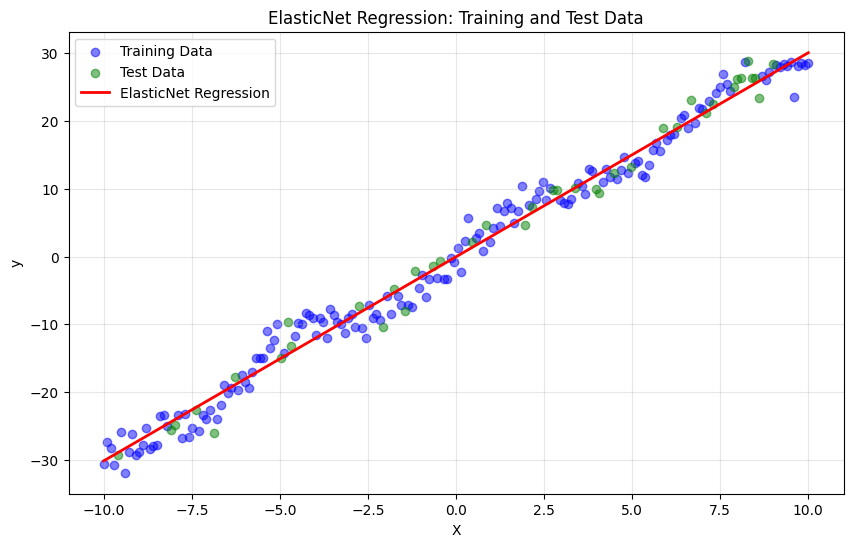

In [16]:
# Load libraries
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(123)
X = np.linspace(-10, 10, 200).reshape(-1, 1)
y = 3*X + np.sin(X) * 2 + np.random.normal(0, 1.5, X.shape)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and fit ElasticNet model
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)  # alpha is regularization strength, l1_ratio balances L1/L2
elastic_net.fit(X_train, y_train)

# Make predictions
y_pred_train = elastic_net.predict(X_train)
y_pred_test = elastic_net.predict(X_test)

# Calculate metrics
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print metrics
print("Training Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"R²: {r2_train:.4f}")
print("\nTest Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')

# Sort X values for smooth line plot
X_plot = np.sort(X, axis=0)
y_plot = elastic_net.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='ElasticNet Regression')

plt.xlabel('X')
plt.ylabel('y')
plt.title('ElasticNet Regression: Training and Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Interpretasi:** tren linear dominan ($3x$) sehingga $R^2$ sangat tinggi; gelombang sinus beramplitudo kecil tidak tertangkap model linear dan muncul sebagai sisa kesalahan.

---
## 8. Ringkasan Bab

Bab ini membahas **regresi linear** (OLS) dan masalahnya pada data berdimensi tinggi/multikolinear, solusi **regularisasi** (Ridge L2, Lasso L1, ElasticNet L1+L2), serta perluasan ke hubungan non-linear lewat **regresi polinomial** dan **spline**, tetap dalam kerangka model linear.

### Rangkuman Konsep dan Fungsi
| Subbab | Konsep utama | Kelas/Fungsi scikit-learn |
|---|---|---|
| Regresi linear | OLS, MSE, $R^2$, asumsi | `LinearRegression`, `mean_squared_error`, `r2_score` |
| Ridge | Penalti L2, koefisien mengecil | `Ridge(alpha=)` |
| Lasso | Penalti L1, seleksi fitur | `Lasso(alpha=)` |
| ElasticNet | Campuran L1+L2, `l1_ratio` | `ElasticNet(alpha=, l1_ratio=)` |
| Polinomial | Fitur berpangkat, derajat | `PolynomialFeatures` |
| Spline | Potongan polinomial, knot | `SplineTransformer`, `make_pipeline` |
| Memilih `alpha` | Cross-validation | `RidgeCV`, `LassoCV` |
| Latihan | Ridge, Lasso, ElasticNet | `train_test_split`, MSE/$R^2$ |

**Pesan utama:** mulai dari baseline linear, **regularisasi** untuk menstabilkan model pada data berkorelasi/berdimensi tinggi, **standardisasi fitur** dan **pilih `alpha` dengan cross-validation**, serta tambahkan polinomial/spline bila hubungan tidak linear.